In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from astropy.table import Table
from astropy.io import fits
import seaborn as sns
from matplotlib.animation import PillowWriter
import matplotlib as mpl
from matplotlib.ticker import FormatStrFormatter
from matplotlib.colors import TwoSlopeNorm

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

import pandas as pd
from astropy.io import fits
from astropy.table import Table

def decode(df):
    """
    Decode DataFrame with byte strings into ordinary strings.
    """
    str_df = df.select_dtypes([object])
    str_df = str_df.stack().str.decode('utf-8').unstack()
    for col in str_df:
        df[col] = str_df[col]
    return df

def fitsrec_to_pandas(fits_rec):
    """
    Convert a FITS_rec object (from astropy.io.fits) to a pandas DataFrame.
    """
    # Convert FITS_rec to astropy Table first
    table = Table(fits_rec)
    
    # Filter out multidimensional columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]
    
    # Convert to pandas DataFrame
    df = table[cols].to_pandas()
    
    # Decode byte strings
    df = decode(df)
    
    return df

def compute_binned_median(df, x_col, y_col, n_bins=12):
    """
    Bin df[x_col] into n_bins, then compute median of df[y_col] in each bin,
    and also return the number of points in each bin.

    Returns columns:
    ['x_bin', f'{y_col}_median', 'x_center', 'count']
    """
    
    # Create bins
    x_bins = np.linspace(df[x_col].min(), df[x_col].max(), n_bins + 1)

    # Bin using pd.cut
    x_bin_labels = pd.cut(df[x_col], bins=x_bins, include_lowest=True)

    # Group by bins and compute median AND count
    grouped = df.groupby(x_bin_labels).agg(
        y_median=(y_col, 'median'),
        count=(y_col, 'size')
    ).reset_index()

    # Add x_center using bin midpoint
    grouped['x_center'] = grouped[x_col].apply(lambda interval: interval.mid)

    # Rename bin column
    grouped = grouped.rename(columns={x_col: 'x_bin', 'y_median': f"{y_col}_median"})

    return grouped


In [17]:
with fits.open('../../data/astroNN_2proc_crossmatch.fits') as hdul:
    astronn_data = hdul[1].data
    twoprocess_data = hdul[2].data

two_process_data = fitsrec_to_pandas(twoprocess_data)
data_astronn = fitsrec_to_pandas(astronn_data)

# Identify columns that are NOT already in two_process_data
#new_cols = data_astronn.columns.difference(two_process_data.columns)
new_cols = ['galr', 'galz']


# Concatenate, keeping two_process_data's versions of duplicate columns
data = pd.concat(
    [
        two_process_data.reset_index(drop=True),
        data_astronn[new_cols].reset_index(drop=True)
    ],
    axis=1
)

data = data[data['DFLAG'] == 0]

data['MG_H'] = data['MG_H_ASPCAP_ADJ']
data['FE_H'] = data['FE_H_ASPCAP_ADJ']
data['MN_H'] = data['MN_H_ASPCAP_ADJ']
data['NI_H'] = data['NI_H_ASPCAP_ADJ']
data['AL_H'] = data['AL_H_ASPCAP_ADJ']

data['MN_O'] = data['MN_H_ASPCAP_ADJ'] - data['O_H_ASPCAP_ADJ']
data['FE_O'] = data['FE_H_ASPCAP_ADJ'] - data['O_H_ASPCAP_ADJ']
data['MN_MG'] = data['MN_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['FE_MG'] = data['FE_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['MG_FE'] = data['MG_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['MN_FE'] = data['MN_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['NI_MG'] = data['NI_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['NI_FE'] = data['NI_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['AL_MG'] = data['AL_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['AL_FE'] = data['AL_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']

data = data[(data['galz'] < 2) & (data['galz'] > -2) & (data['galr'] < 15) & (data['galr'] > 3)]

pos_FE_H = data[(data['FE_H'] > 0)]
neg_FE_H = data[(data['FE_H'] < 0)]
data_high_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] > 0.12)], neg_FE_H[neg_FE_H['MG_FE'] > 0.12 - 0.13 * neg_FE_H['FE_H']]])
data_low_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] < 0.12)], neg_FE_H[neg_FE_H['MG_FE'] < 0.12 - 0.13 * neg_FE_H['FE_H']]])


data_high_alpha['high_low_alpha'] = "high"
data_low_alpha['high_low_alpha'] = "low"
data_high_alpha['color'] = "hotpink"
data_low_alpha['color'] = "cornflowerblue"

data = pd.concat([data_high_alpha, data_low_alpha], ignore_index=True)

#data = data[data['LOGG'] > 1.4]

In [18]:
from chemevo import evolution_V1 as evo

mg_h_big_bin_edges = np.arange(-0.8, 0.4, 0.2) 
mg_h_big_bin_centers = 0.5 * (mg_h_big_bin_edges[:-1] + mg_h_big_bin_edges[1:])

data['MG_H_big_bin'] = pd.cut(data['MG_H'], bins = mg_h_big_bin_edges, right=False, labels=False)

xs = np.linspace(-1, 1, 100)

def downsample(df, N):
    if len(df) > N:
        return df.sample(N, random_state=42)   # random subset of N
    else:
        return df
    
t_array = np.linspace(0.0001,14,int(1e3))
t_array_trunc = np.linspace(0.0001,6,int(1e3))
dt = t_array[1] - t_array[0]

def rise_fall(t, tau_1, tau_2):
    return 1 * (1 - np.exp(-t/tau_1)) * np.exp(-t/tau_2)

m_g_array_const = np.ones(len(t_array))
tau_sfh = 6 #Gyrs
m_g_array_exp = 1 * np.exp(-t_array/tau_sfh)
m_g_array_exp /= np.trapezoid(m_g_array_exp, t_array)
m_g_array_rise_fall = rise_fall(t_array, 2, 8)
m_g_array_rise_fall /= np.trapezoid(m_g_array_rise_fall, t_array)

etas = [0, 0.5, 1, 2]
tau_stars = [0.5, 1, 1.5, 2, 2.5, 3, 4, 5, 6]
gcc_Mn_this_notebook = 0.25
gcc_ratio_this_notebook = 2



gals_A = [] #gcc = 0.35, g_ratio = 2, Ups = 1, eta = 0, SFH = constant
for i in range(len(tau_stars)):
    gals_A.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_rise_fall, tau_star=tau_stars[i], eta=etas[0],
                             g_cc_Mn=gcc_Mn_this_notebook, g_ratio_Mn=gcc_ratio_this_notebook, Upsilon=1))

gals_B = [] #gcc = 0.35, g_ratio = 2, Ups = 1.5, eta = 0, SFH = constant
for i in range(len(tau_stars)):
    gals_B.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_rise_fall, tau_star=tau_stars[i], eta=etas[0],
                             g_cc_Mn=gcc_Mn_this_notebook, g_ratio_Mn=gcc_ratio_this_notebook, Upsilon=1.5))

gals_C = [] #gcc = 0.35, g_ratio = 2, Ups = 2, eta = 0, SFH = constant
for i in range(len(tau_stars)):
    gals_C.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_rise_fall, tau_star=tau_stars[i], eta=etas[0],
                             g_cc_Mn=gcc_Mn_this_notebook, g_ratio_Mn=gcc_ratio_this_notebook, Upsilon=2))
    
###########
gals_D = [] #gcc = 0.35, g_ratio = 2, Ups = 1, eta = 1, SFH = constant
for i in range(len(tau_stars)):
    gals_D.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_rise_fall, tau_star=tau_stars[i], eta=1,
                             g_cc_Mn=gcc_Mn_this_notebook, g_ratio_Mn=gcc_ratio_this_notebook, Upsilon=1))

gals_E = [] #gcc = 0.35, g_ratio = 2, Ups = 1.5, eta = 1, SFH = constant
for i in range(len(tau_stars)):
    gals_E.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_rise_fall, tau_star=tau_stars[i], eta=1,
                             g_cc_Mn=gcc_Mn_this_notebook, g_ratio_Mn=gcc_ratio_this_notebook, Upsilon=1.5))

gals_F = [] #gcc = 0.35, g_ratio = 2, Ups = 2, eta = 1, SFH = constant
for i in range(len(tau_stars)):
    gals_F.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_rise_fall, tau_star=tau_stars[i], eta=1,
                             g_cc_Mn=gcc_Mn_this_notebook, g_ratio_Mn=gcc_ratio_this_notebook, Upsilon=2))
############
gals_G = [] #gcc = 0.35, g_ratio = 2, Ups = 1, eta = 0.5, SFH = constant
for i in range(len(tau_stars)):
    gals_G.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_rise_fall, tau_star=tau_stars[i], eta=0.5,
                             g_cc_Mn=gcc_Mn_this_notebook, g_ratio_Mn=gcc_ratio_this_notebook, Upsilon=1))

gals_H = [] #gcc = 0.35, g_ratio = 2, Ups = 1.5, eta = 0.5, SFH = constant
for i in range(len(tau_stars)):
    gals_H.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_rise_fall, tau_star=tau_stars[i], eta=0.5,
                             g_cc_Mn=gcc_Mn_this_notebook, g_ratio_Mn=gcc_ratio_this_notebook, Upsilon=1.5))

gals_I = [] #gcc = 0.35, g_ratio = 2, Ups = 2, eta = 0.5, SFH = constant
for i in range(len(tau_stars)):
    gals_I.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_rise_fall, tau_star=tau_stars[i], eta=0.5,
                             g_cc_Mn=gcc_Mn_this_notebook, g_ratio_Mn=gcc_ratio_this_notebook, Upsilon=2))
    
#############
gals_J = [] #gcc = 0.35, g_ratio = 2, Ups = 1, eta = 2, SFH = constant
for i in range(len(tau_stars)):
    gals_J.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_rise_fall, tau_star=tau_stars[i], eta=2,
                             g_cc_Mn=gcc_Mn_this_notebook, g_ratio_Mn=gcc_ratio_this_notebook, Upsilon=1))

gals_K = [] #gcc = 0.35, g_ratio = 2, Ups = 1.5, eta = 2, SFH = constant
for i in range(len(tau_stars)):
    gals_K.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_rise_fall, tau_star=tau_stars[i], eta=2,
                             g_cc_Mn=gcc_Mn_this_notebook, g_ratio_Mn=gcc_ratio_this_notebook, Upsilon=1.5))

gals_L = [] #gcc = 0.35, g_ratio = 2, Ups = 2, eta = 2, SFH = constant
for i in range(len(tau_stars)):
    gals_L.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_rise_fall, tau_star=tau_stars[i], eta=2,
                             g_cc_Mn=gcc_Mn_this_notebook, g_ratio_Mn=gcc_ratio_this_notebook, Upsilon=2))

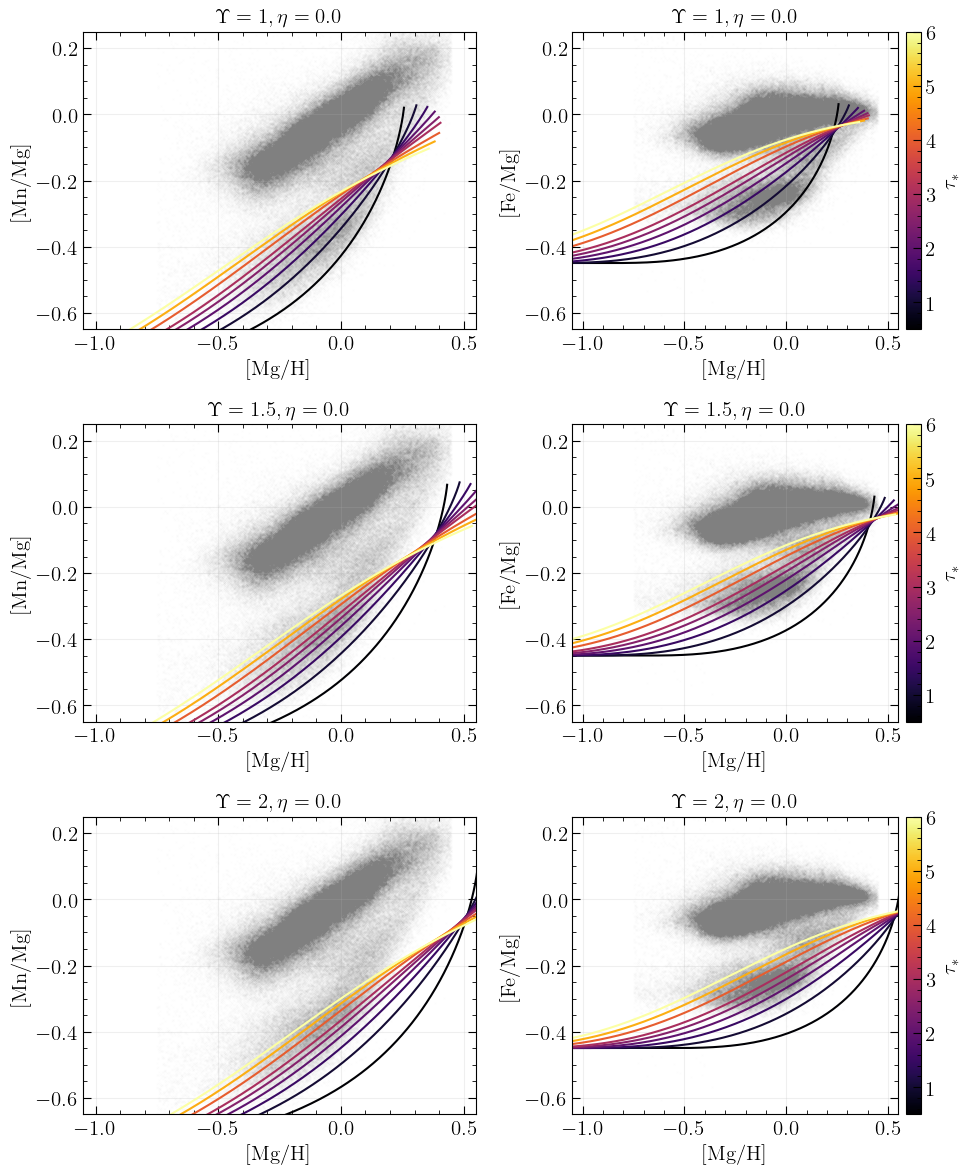

In [19]:
ABC_gals = [gals_A, gals_B, gals_C]
import matplotlib as mpl

# collect all tau_* values
tau_vals = [gal.tau_star_arr[0]
            for gals in ABC_gals
            for gal in gals]

norm = mpl.colors.Normalize(vmin=min(tau_vals), vmax=max(tau_vals))
cmap = mpl.cm.inferno  # grayscale colormap
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

plt.figure(figsize=(10,12))

for i in range(3):
    plt.subplot(3,2,2*i+1)
    plt.scatter(data['MG_H'], data['MN_MG'], alpha = 0.01, color = 'gray', s = 0.5)
    gals = ABC_gals[i]
    for j in range(len(gals)):
        gal = gals[j]
        color = cmap(norm(gal.tau_star_arr[0]))
        plt.plot(gal.Mg_H, gal.Mn_Mg, color = color, linestyle='-')
        plt.grid('True', alpha = 0.2)
    plt.title(rf"$\Upsilon = {gal.Upsilon}, \eta = {gal.eta_arr[0]}$")
    plt.xlabel('[Mg/H]')
    plt.ylabel('[Mn/Mg]')
    plt.ylim(-0.65,0.25)
    plt.xlim(-1.05,0.55)
    plt.tight_layout()

    ax_right = plt.subplot(3,2,2*(i+1))
    plt.subplot(3,2,2*(i+1))
    plt.scatter(data['MG_H'], data['FE_MG'], alpha = 0.01, color = 'gray', s = 0.5)
    for j in range(len(gals)):
        gal = gals[j]
        color = cmap(norm(gal.tau_star_arr[0]))
        plt.plot(gal.Mg_H[1:], gal.Fe_Mg[1:], label = rf'$\tau_* = {gal.tau_star_arr[0]}$', color = color)
        plt.grid('True', alpha = 0.2)
    plt.xlabel('[Mg/H]')
    plt.ylabel('[Fe/Mg]')
    plt.ylim(-0.65,0.25)
    plt.xlim(-1.05,0.55)
    plt.title(rf"$\Upsilon = {gal.Upsilon}, \eta = {gal.eta_arr[0]}$")
    cbar = plt.colorbar(sm, ax=ax_right, pad=0.02)
    cbar.set_label(r'$\tau_*$')
    plt.tight_layout()


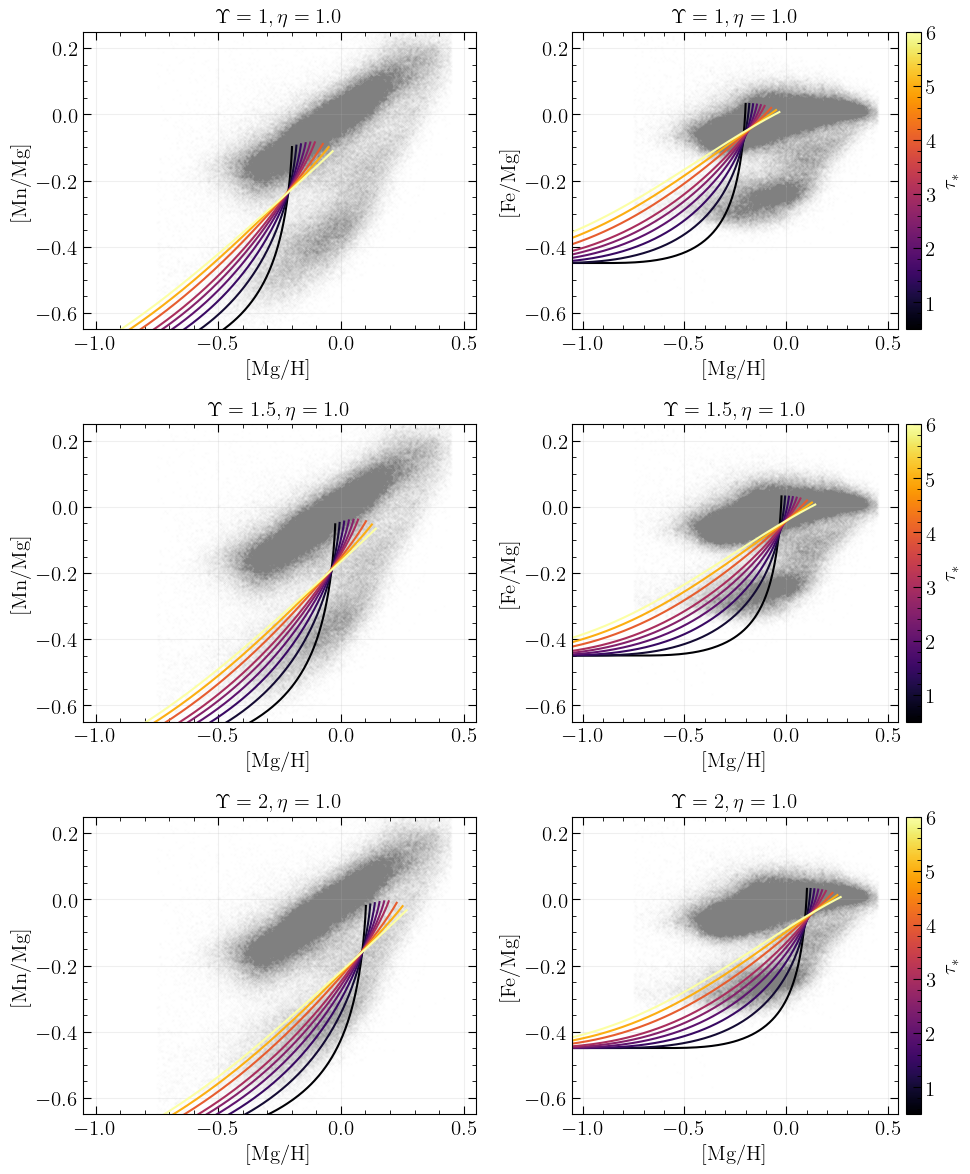

In [20]:
ABC_gals = [gals_D, gals_E, gals_F]
import matplotlib as mpl

# collect all tau_* values
tau_vals = [gal.tau_star_arr[0]
            for gals in ABC_gals
            for gal in gals]

norm = mpl.colors.Normalize(vmin=min(tau_vals), vmax=max(tau_vals))
cmap = mpl.cm.inferno  # grayscale colormap
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

plt.figure(figsize=(10,12))

for i in range(3):
    plt.subplot(3,2,2*i+1)
    plt.scatter(data['MG_H'], data['MN_MG'], alpha = 0.01, color = 'gray', s = 0.5)
    gals = ABC_gals[i]
    for j in range(len(gals)):
        gal = gals[j]
        color = cmap(norm(gal.tau_star_arr[0]))
        plt.plot(gal.Mg_H, gal.Mn_Mg, color = color, linestyle='-')
        plt.grid('True', alpha = 0.2)
    plt.title(rf"$\Upsilon = {gal.Upsilon}, \eta = {gal.eta_arr[0]}$")
    plt.xlabel('[Mg/H]')
    plt.ylabel('[Mn/Mg]')
    plt.ylim(-0.65,0.25)
    plt.xlim(-1.05,0.55)
    plt.tight_layout()

    ax_right = plt.subplot(3,2,2*(i+1))
    plt.subplot(3,2,2*(i+1))
    plt.scatter(data['MG_H'], data['FE_MG'], alpha = 0.01, color = 'gray', s = 0.5)
    for j in range(len(gals)):
        gal = gals[j]
        color = cmap(norm(gal.tau_star_arr[0]))
        plt.plot(gal.Mg_H[1:], gal.Fe_Mg[1:], label = rf'$\tau_* = {gal.tau_star_arr[0]}$', color = color)
        plt.grid('True', alpha = 0.2)
    plt.xlabel('[Mg/H]')
    plt.ylabel('[Fe/Mg]')
    plt.ylim(-0.65,0.25)
    plt.xlim(-1.05,0.55)
    plt.title(rf"$\Upsilon = {gal.Upsilon}, \eta = {gal.eta_arr[0]}$")
    cbar = plt.colorbar(sm, ax=ax_right, pad=0.02)
    cbar.set_label(r'$\tau_*$')
    plt.tight_layout()


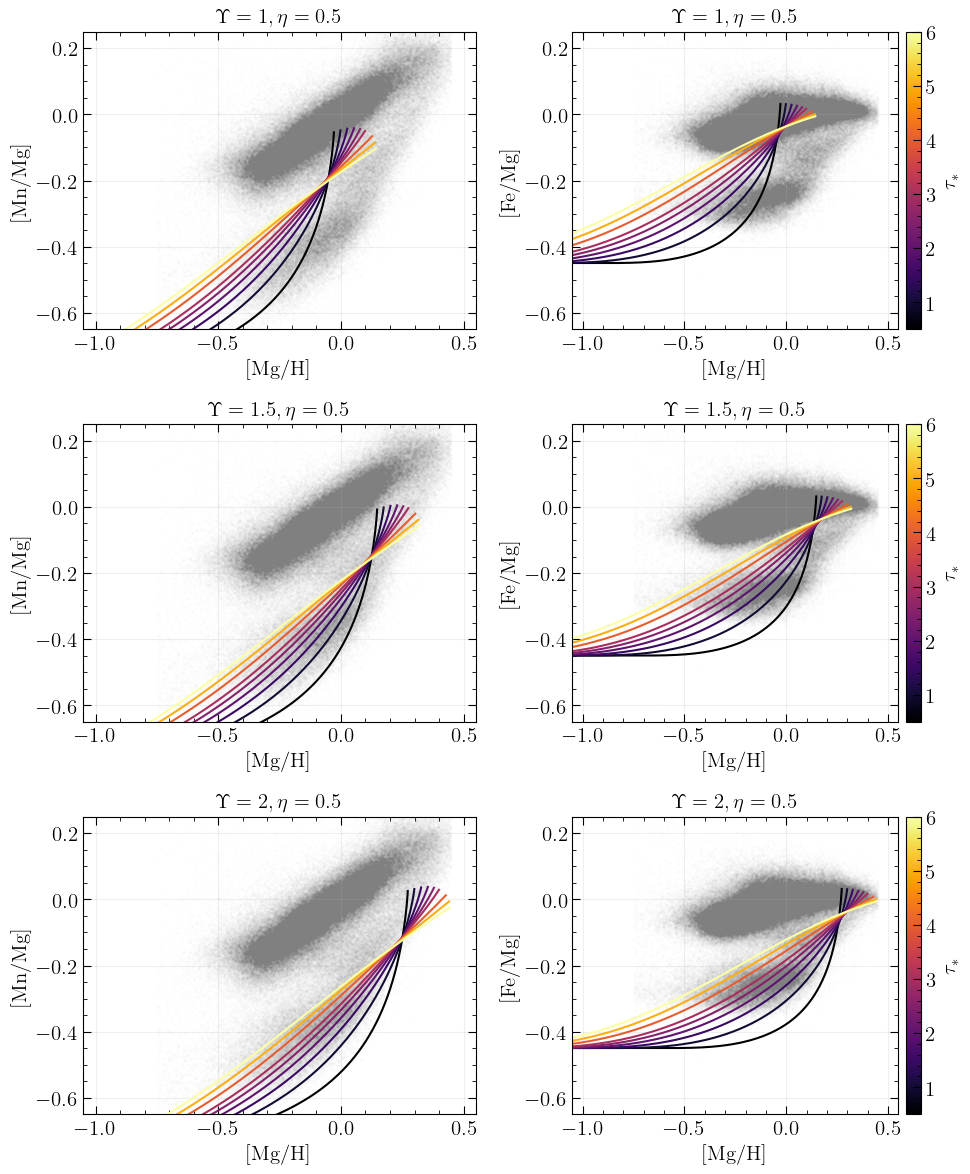

In [21]:
ABC_gals = [gals_G, gals_H, gals_I]
import matplotlib as mpl

# collect all tau_* values
tau_vals = [gal.tau_star_arr[0]
            for gals in ABC_gals
            for gal in gals]

norm = mpl.colors.Normalize(vmin=min(tau_vals), vmax=max(tau_vals))
cmap = mpl.cm.inferno  # grayscale colormap
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

plt.figure(figsize=(10,12))

for i in range(3):
    plt.subplot(3,2,2*i+1)
    plt.scatter(data['MG_H'], data['MN_MG'], alpha = 0.01, color = 'gray', s = 0.5)
    gals = ABC_gals[i]
    for j in range(len(gals)):
        gal = gals[j]
        color = cmap(norm(gal.tau_star_arr[0]))
        plt.plot(gal.Mg_H, gal.Mn_Mg, color = color, linestyle='-')
        plt.grid('True', alpha = 0.2)
    plt.title(rf"$\Upsilon = {gal.Upsilon}, \eta = {gal.eta_arr[0]}$")
    plt.xlabel('[Mg/H]')
    plt.ylabel('[Mn/Mg]')
    plt.ylim(-0.65,0.25)
    plt.xlim(-1.05,0.55)
    plt.tight_layout()

    ax_right = plt.subplot(3,2,2*(i+1))
    plt.subplot(3,2,2*(i+1))
    plt.scatter(data['MG_H'], data['FE_MG'], alpha = 0.01, color = 'gray', s = 0.5)
    for j in range(len(gals)):
        gal = gals[j]
        color = cmap(norm(gal.tau_star_arr[0]))
        plt.plot(gal.Mg_H[1:], gal.Fe_Mg[1:], label = rf'$\tau_* = {gal.tau_star_arr[0]}$', color = color)
        plt.grid('True', alpha = 0.2)
    plt.xlabel('[Mg/H]')
    plt.ylabel('[Fe/Mg]')
    plt.ylim(-0.65,0.25)
    plt.xlim(-1.05,0.55)
    plt.title(rf"$\Upsilon = {gal.Upsilon}, \eta = {gal.eta_arr[0]}$")
    cbar = plt.colorbar(sm, ax=ax_right, pad=0.02)
    cbar.set_label(r'$\tau_*$')
    plt.tight_layout()


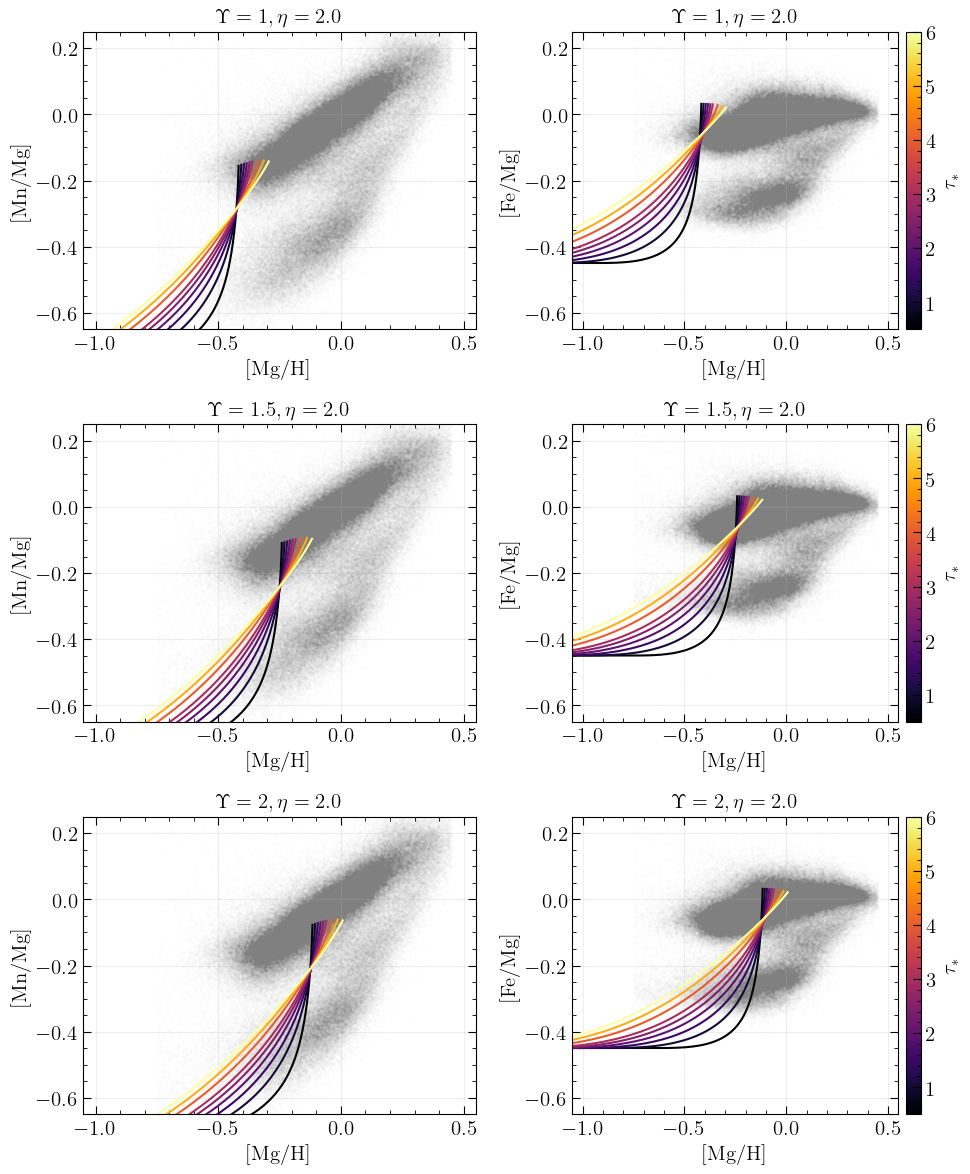

In [22]:
ABC_gals = [gals_J, gals_K, gals_L]
import matplotlib as mpl

# collect all tau_* values
tau_vals = [gal.tau_star_arr[0]
            for gals in ABC_gals
            for gal in gals]

norm = mpl.colors.Normalize(vmin=min(tau_vals), vmax=max(tau_vals))
cmap = mpl.cm.inferno  # grayscale colormap
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

plt.figure(figsize=(10,12))

for i in range(3):
    plt.subplot(3,2,2*i+1)
    plt.scatter(data['MG_H'], data['MN_MG'], alpha = 0.01, color = 'gray', s = 0.5)
    gals = ABC_gals[i]
    for j in range(len(gals)):
        gal = gals[j]
        color = cmap(norm(gal.tau_star_arr[0]))
        plt.plot(gal.Mg_H, gal.Mn_Mg, color = color, linestyle='-')
        plt.grid('True', alpha = 0.2)
    plt.title(rf"$\Upsilon = {gal.Upsilon}, \eta = {gal.eta_arr[0]}$")
    plt.xlabel('[Mg/H]')
    plt.ylabel('[Mn/Mg]')
    plt.ylim(-0.65,0.25)
    plt.xlim(-1.05,0.55)
    plt.tight_layout()

    ax_right = plt.subplot(3,2,2*(i+1))
    plt.subplot(3,2,2*(i+1))
    plt.scatter(data['MG_H'], data['FE_MG'], alpha = 0.01, color = 'gray', s = 0.5)
    for j in range(len(gals)):
        gal = gals[j]
        color = cmap(norm(gal.tau_star_arr[0]))
        plt.plot(gal.Mg_H[1:], gal.Fe_Mg[1:], label = rf'$\tau_* = {gal.tau_star_arr[0]}$', color = color)
        plt.grid('True', alpha = 0.2)
    plt.xlabel('[Mg/H]')
    plt.ylabel('[Fe/Mg]')
    plt.ylim(-0.65,0.25)
    plt.xlim(-1.05,0.55)
    plt.title(rf"$\Upsilon = {gal.Upsilon}, \eta = {gal.eta_arr[0]}$")
    cbar = plt.colorbar(sm, ax=ax_right, pad=0.02)
    cbar.set_label(r'$\tau_*$')
    plt.tight_layout()


In [23]:
def find_endpoints(galaxies, bin_centers):
    endpoints_gals = []

    for bin_cent in bin_centers:
        endpoints = []
        for gal in galaxies:
            mg_h = gal.Mg_H
            for indx in range(len(mg_h)):
                mg_h_at_time = mg_h[indx]
                if mg_h_at_time > bin_cent:
                    endpoints.append(indx)
                    break

        endpoints_gals.append(np.array(endpoints))

    return endpoints_gals

downsampled_data = downsample(data[data['MG_H_big_bin'] == i], 5000)

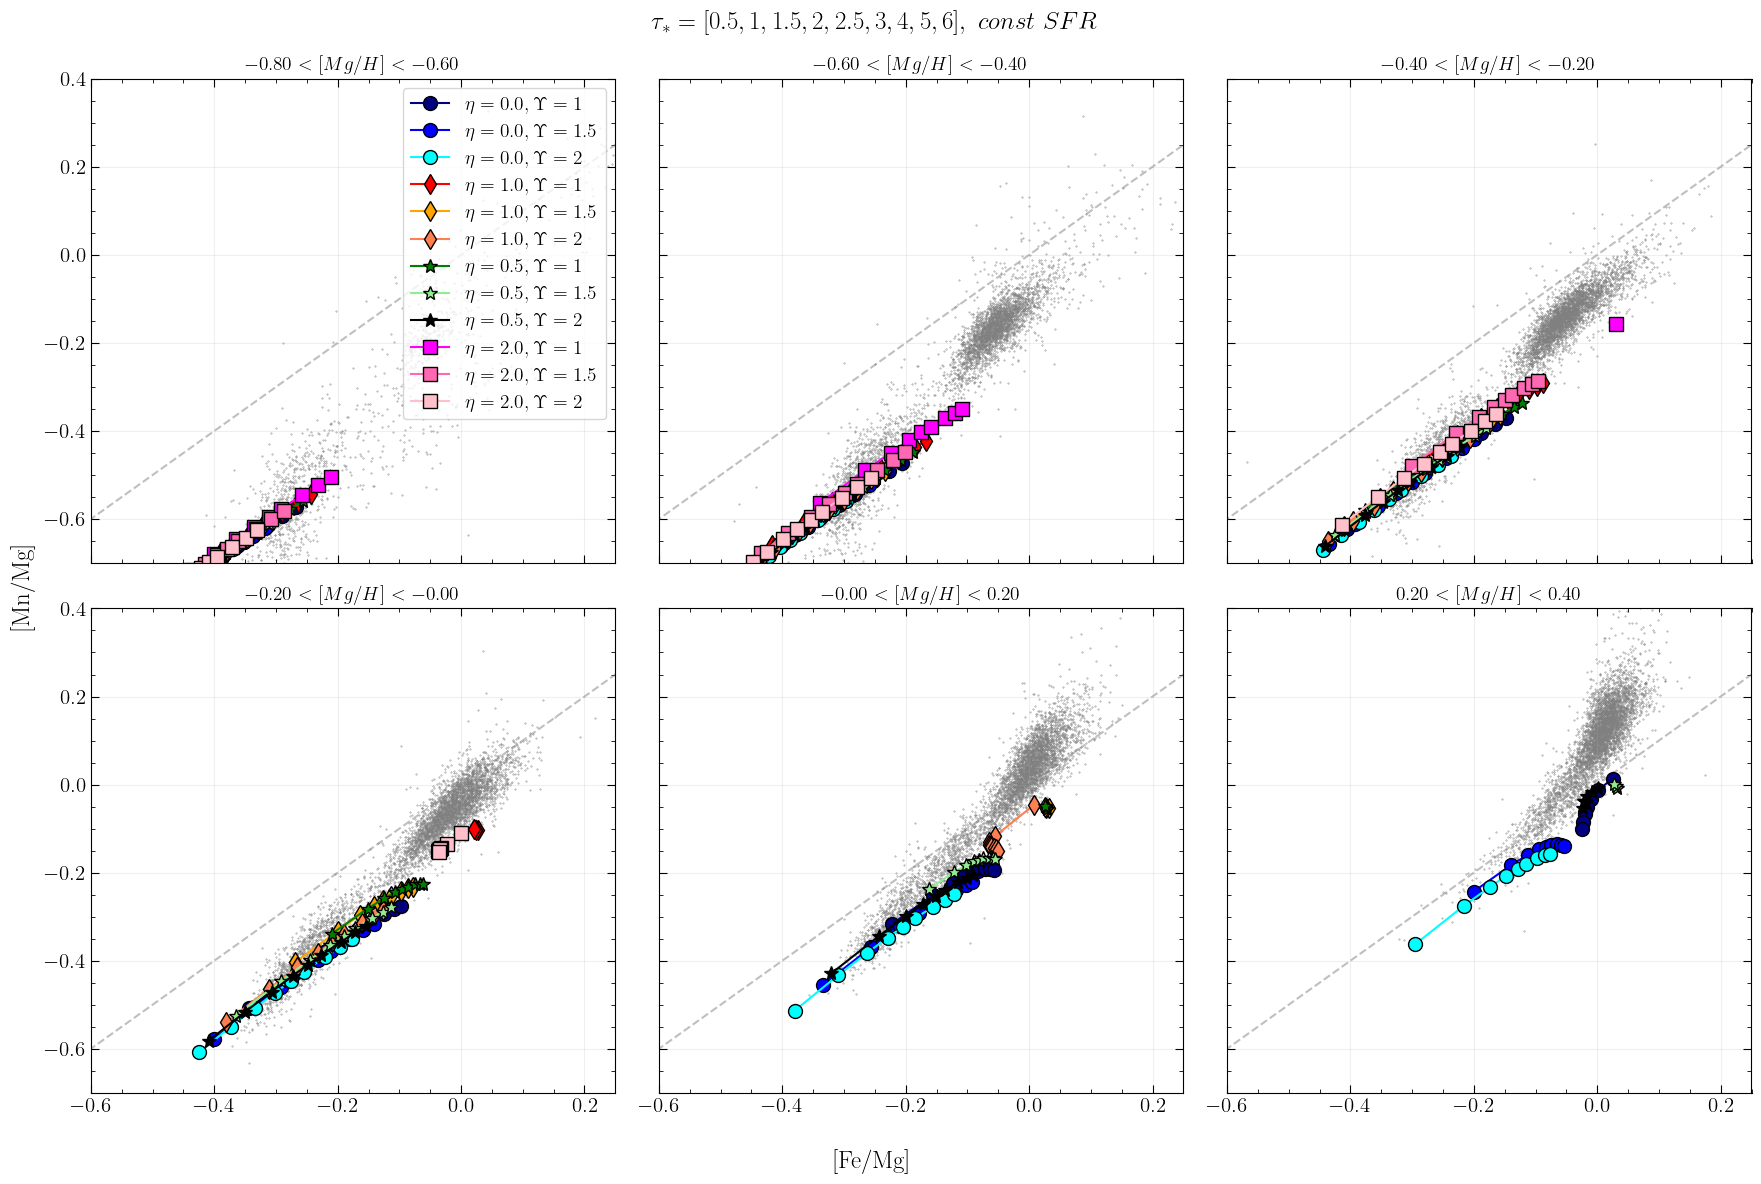

In [24]:
which_ep = 1
#gals = [gals_A, gals_B, gals_C]
#gals = [gals_D, gals_E, gals_F]
#gals = [gals_G, gals_H, gals_I]
#gals = [gals_J, gals_K, gals_L]
gals = [gals_A, gals_B, gals_C, gals_D, gals_E, gals_F, gals_G, gals_H, gals_I, gals_J, gals_K, gals_L]


gals_endpoints = {
    j: find_endpoints(gals[j], mg_h_big_bin_centers)
    for j in range(len(gals))
}

colors = ['navy', 'blue', 'cyan', 'red', 'orange', 'coral', 'green', 'lightgreen', 'black', 'magenta', 'hotpink', 'pink']
shapes = ['o', 'o', 'o', 'd', 'd', 'd', '*', '*', '*', 's', 's', 's']

fig, axes = plt.subplots(2, 3, figsize=(18, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes):

    # Background data
    downsampled_data = downsample(data[data['MG_H_big_bin'] == i], 5000)
    ax.scatter(downsampled_data['FE_MG'], downsampled_data['MN_MG'], s=0.1, color='gray')

    # 1:1 line
    xs = np.linspace(-1, 1, 100)
    ax.plot(xs, xs, '--', alpha=0.5, color='gray')

    # τ_* sequences for all gcc values
    for j, (gals_j, endpoints_j, color, shape) in enumerate(
        zip(gals, gals_endpoints.values(), colors, shapes)
    ):
        idxs = endpoints_j[i]

        fe_mg = [gal.Fe_Mg[idx] for gal, idx in zip(gals_j, idxs)]
        mn_mg = [gal.Mn_Mg[idx] for gal, idx in zip(gals_j, idxs)]
        example_gal = gals_j[0]
        ax.plot(fe_mg, mn_mg, marker=shape, color=color, linewidth=1.5,
                label = rf"$\eta = {example_gal.eta_arr[0]}, \Upsilon = {example_gal.Upsilon}$",
                markeredgecolor='black', markersize=10)
        
    if i == 0:
        ax.legend(loc = 'upper right')

    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.70, 0.40)

fig.supxlabel('[Fe/Mg]')
fig.supylabel('[Mn/Mg]')
fig.suptitle(rf"$\tau_* = {tau_stars}, \ const\ SFR$")
plt.tight_layout()
plt.show()


In [25]:
fig_x = 15
fig_y = 12

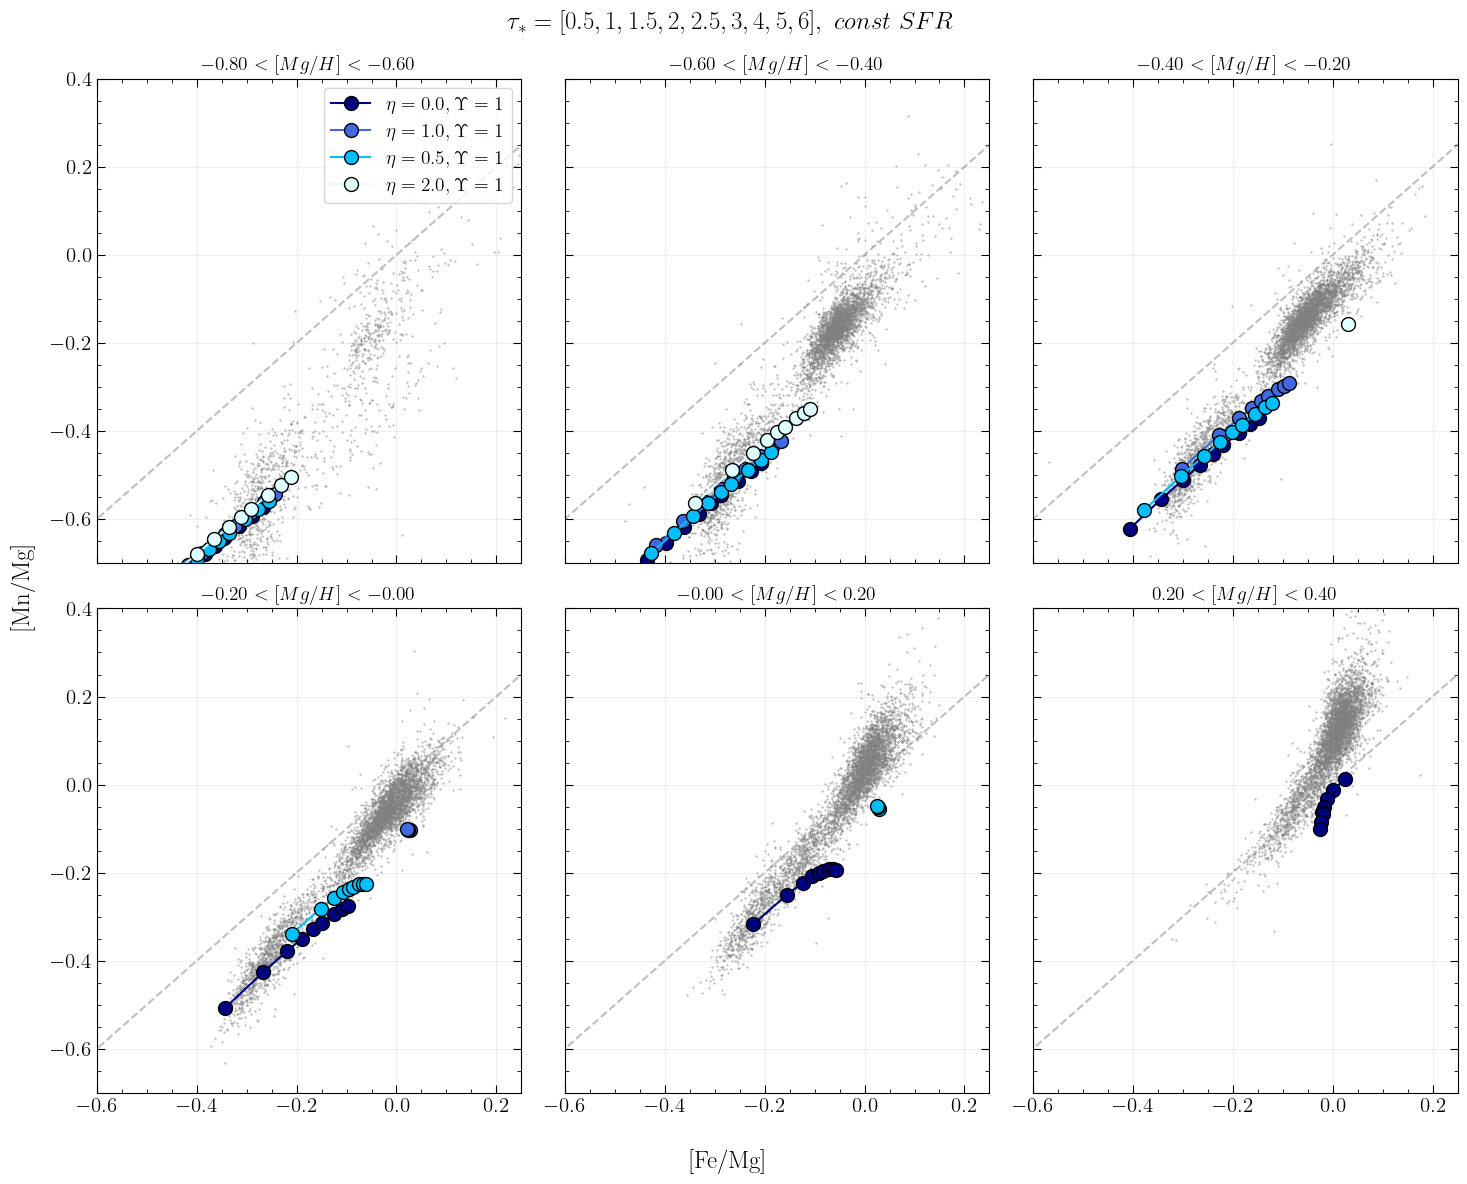

In [26]:
#gals = [gals_A, gals_B, gals_C,
# gals_D, gals_E, gals_F,
# gals_G, gals_H, gals_I,
# gals_J, gals_K, gals_L]
gals = [gals_A, gals_D, gals_G, gals_J] #ups = 1
#gals = [gals_B, gals_E, gals_H, gals_K] #ups = 1.5
#gals = [gals_C, gals_F, gals_I, gals_L] #ups = 2
#gals = [gals_A, gals_D, gals_G, gals_J, gals_B, gals_E, gals_H, gals_K, gals_C, gals_F, gals_I, gals_L]

gals_endpoints = {
    j: find_endpoints(gals[j], mg_h_big_bin_centers)
    for j in range(len(gals))
}

#colors = ['navy', 'royalblue', 'deepskyblue', 'lightcyan', 'darkred', 'firebrick','orangered', 'lightsalmon', 'darkgreen', 'forestgreen', 'limegreen','palegreen', 'indigo', 'purple', 'mediumorchid', 'plum']
colors = ['navy', 'royalblue', 'deepskyblue', 'lightcyan'] #ups = 1
#colors = ['darkred', 'firebrick','orangered', 'lightsalmon'] #ups = 1.5
#colors = ['darkgreen', 'forestgreen', 'limegreen','palegreen'] #ups = 2
#colors = ['indigo', 'purple', 'mediumorchid', 'plum'] #backup



shapes = ['o', 'o', 'o', 'o', 'd', 'd', 'd', 'd', 's', 's', 's', 's']

fig, axes = plt.subplots(2, 3, figsize=(fig_x, fig_y), sharex=True, sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes):

    # Background data
    downsampled_data = downsample(data[data['MG_H_big_bin'] == i], 5000)
    ax.scatter(downsampled_data['FE_MG'], downsampled_data['MN_MG'], s=0.1, color='gray')

    # 1:1 line
    xs = np.linspace(-1, 1, 100)
    ax.plot(xs, xs, '--', alpha=0.5, color='gray')

    # τ_* sequences for all gcc values
    for j, (gals_j, endpoints_j, color, shape) in enumerate(
        zip(gals, gals_endpoints.values(), colors, shapes)
    ):
        idxs = endpoints_j[i]

        fe_mg = [gal.Fe_Mg[idx] for gal, idx in zip(gals_j, idxs)]
        mn_mg = [gal.Mn_Mg[idx] for gal, idx in zip(gals_j, idxs)]
        example_gal = gals_j[0]
        ax.plot(fe_mg, mn_mg, marker=shape, color=color, linewidth=1.5,
                label = rf"$\eta = {example_gal.eta_arr[0]}, \Upsilon = {example_gal.Upsilon}$",
                markeredgecolor='black', markersize=10)
        
    if i == 0:
        ax.legend(loc = 'upper right')

    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.70, 0.40)

fig.supxlabel('[Fe/Mg]')
fig.supylabel('[Mn/Mg]')
fig.suptitle(rf"$\tau_* = {tau_stars}, \ const\ SFR$")
plt.tight_layout()
plt.show()


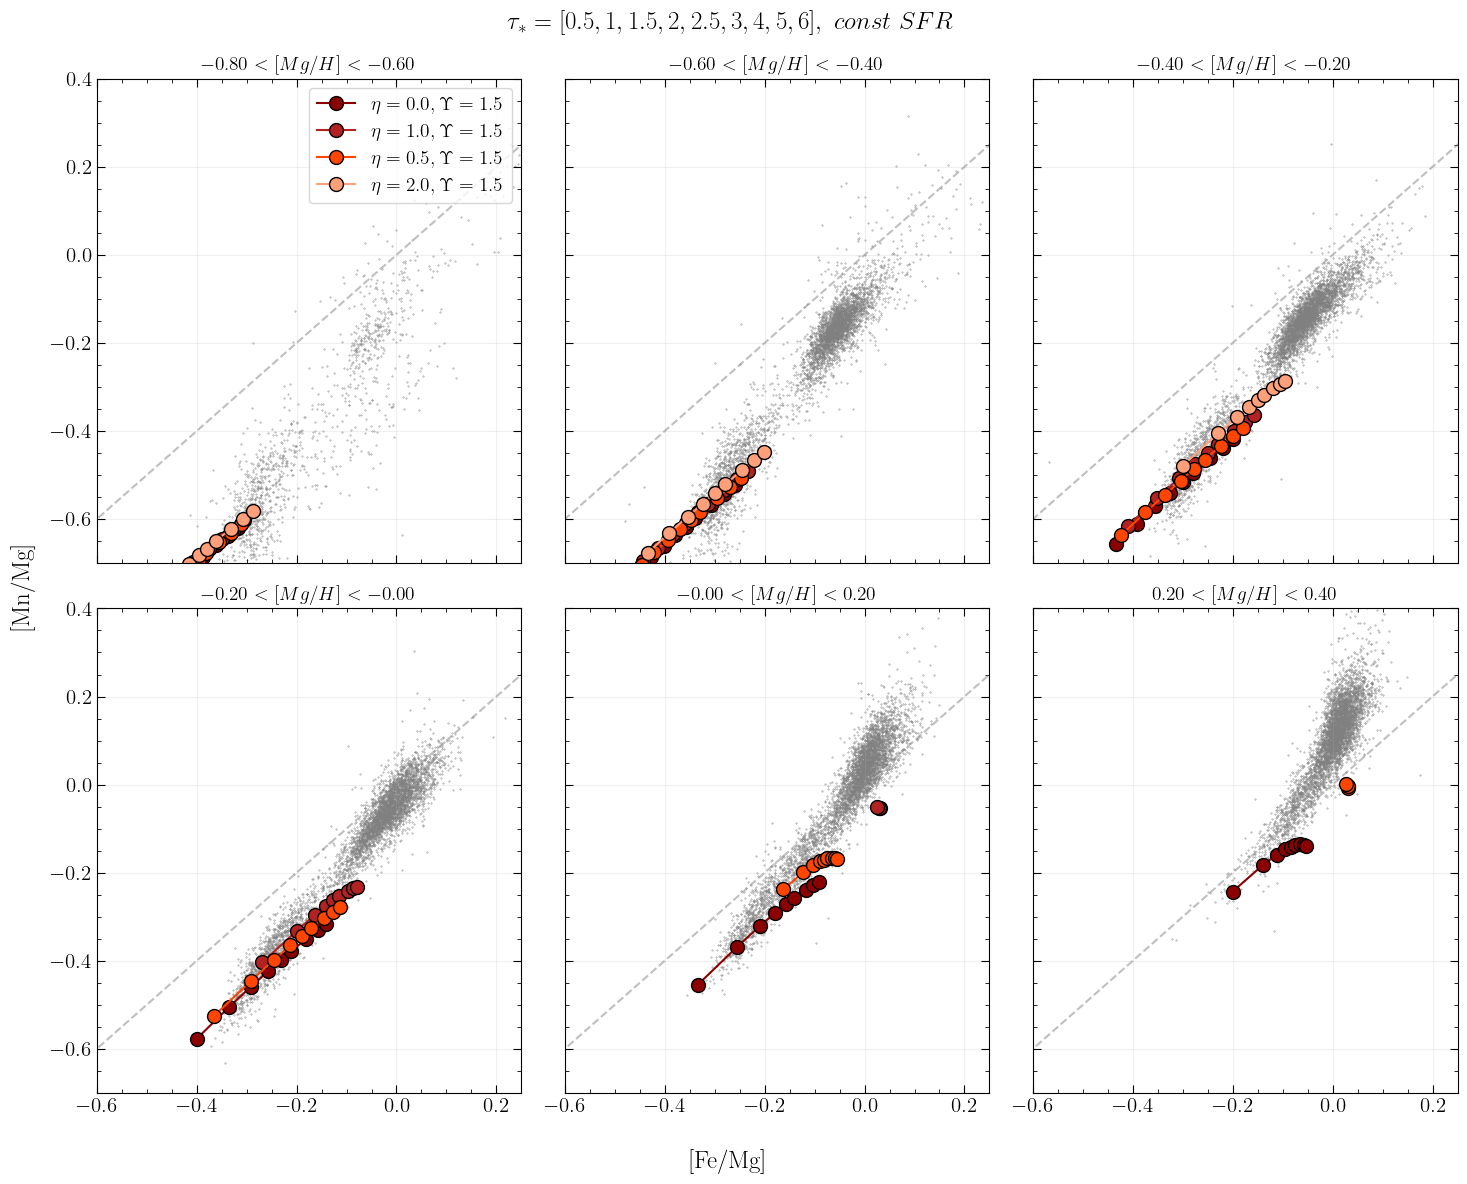

In [27]:
#gals = [gals_A, gals_B, gals_C,
# gals_D, gals_E, gals_F,
# gals_G, gals_H, gals_I,
# gals_J, gals_K, gals_L]
#gals = [gals_A, gals_D, gals_G, gals_J] #ups = 1
gals = [gals_B, gals_E, gals_H, gals_K] #ups = 1.5
#gals = [gals_C, gals_F, gals_I, gals_L] #ups = 2
#gals = [gals_A, gals_D, gals_G, gals_J, gals_B, gals_E, gals_H, gals_K, gals_C, gals_F, gals_I, gals_L]

gals_endpoints = {
    j: find_endpoints(gals[j], mg_h_big_bin_centers)
    for j in range(len(gals))
}

#colors = ['navy', 'royalblue', 'deepskyblue', 'lightcyan', 'darkred', 'firebrick','orangered', 'lightsalmon', 'darkgreen', 'forestgreen', 'limegreen','palegreen', 'indigo', 'purple', 'mediumorchid', 'plum']
#colors = ['navy', 'royalblue', 'deepskyblue', 'lightcyan'] #ups = 1
colors = ['darkred', 'firebrick','orangered', 'lightsalmon'] #ups = 1.5
#colors = ['indigo', 'purple', 'mediumorchid', 'plum']
#colors = ['darkgreen', 'forestgreen', 'limegreen','palegreen']


shapes = ['o', 'o', 'o', 'o', 'd', 'd', 'd', 'd', 's', 's', 's', 's']

fig, axes = plt.subplots(2, 3, figsize=(fig_x, fig_y), sharex=True, sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes):

    # Background data
    downsampled_data = downsample(data[data['MG_H_big_bin'] == i], 5000)
    ax.scatter(downsampled_data['FE_MG'], downsampled_data['MN_MG'], s=0.1, color='gray')

    # 1:1 line
    xs = np.linspace(-1, 1, 100)
    ax.plot(xs, xs, '--', alpha=0.5, color='gray')

    # τ_* sequences for all gcc values
    for j, (gals_j, endpoints_j, color, shape) in enumerate(
        zip(gals, gals_endpoints.values(), colors, shapes)
    ):
        idxs = endpoints_j[i]

        fe_mg = [gal.Fe_Mg[idx] for gal, idx in zip(gals_j, idxs)]
        mn_mg = [gal.Mn_Mg[idx] for gal, idx in zip(gals_j, idxs)]
        example_gal = gals_j[0]
        ax.plot(fe_mg, mn_mg, marker=shape, color=color, linewidth=1.5,
                label = rf"$\eta = {example_gal.eta_arr[0]}, \Upsilon = {example_gal.Upsilon}$",
                markeredgecolor='black', markersize=10)
        
    if i == 0:
        ax.legend(loc = 'upper right')

    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.70, 0.40)

fig.supxlabel('[Fe/Mg]')
fig.supylabel('[Mn/Mg]')
fig.suptitle(rf"$\tau_* = {tau_stars}, \ const\ SFR$")
plt.tight_layout()
plt.show()


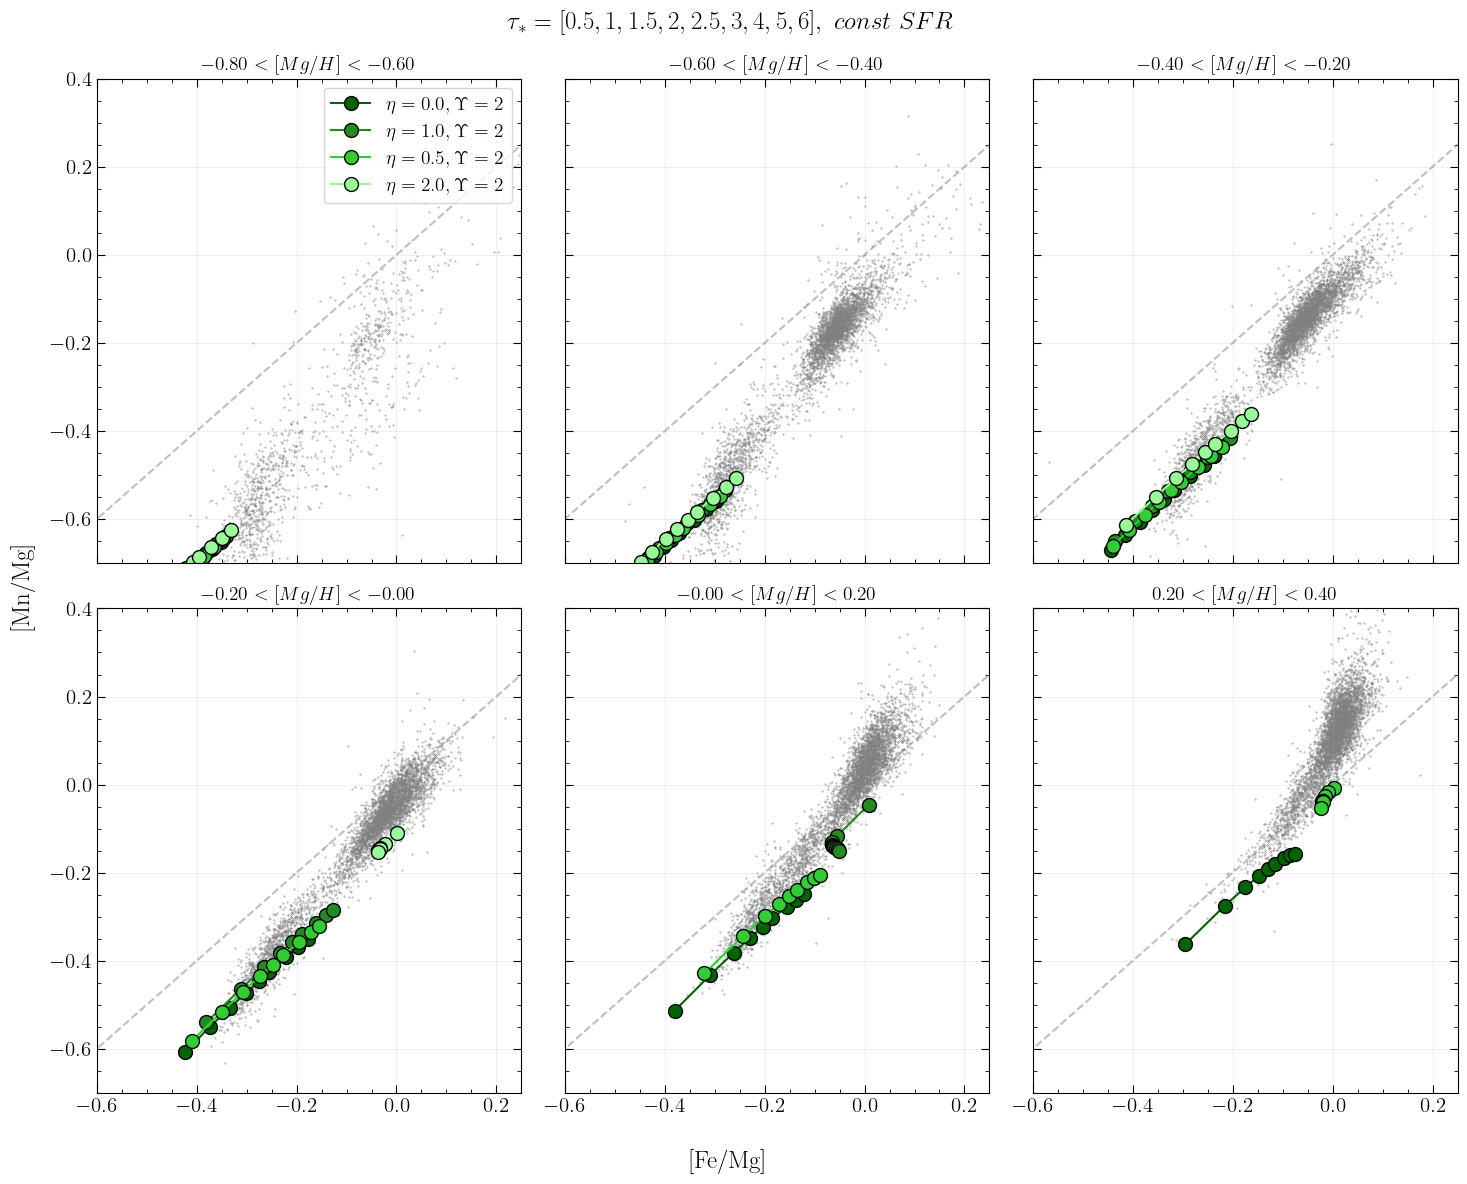

In [28]:
#gals = [gals_A, gals_B, gals_C,
# gals_D, gals_E, gals_F,
# gals_G, gals_H, gals_I,
# gals_J, gals_K, gals_L]
#gals = [gals_A, gals_D, gals_G, gals_J] #ups = 1
#gals = [gals_B, gals_E, gals_H, gals_K] #ups = 1.5
gals = [gals_C, gals_F, gals_I, gals_L] #ups = 2
#gals = [gals_A, gals_D, gals_G, gals_J, gals_B, gals_E, gals_H, gals_K, gals_C, gals_F, gals_I, gals_L]

gals_endpoints = {
    j: find_endpoints(gals[j], mg_h_big_bin_centers)
    for j in range(len(gals))
}

#colors = ['navy', 'royalblue', 'deepskyblue', 'lightcyan', 'darkred', 'firebrick','orangered', 'lightsalmon', 'darkgreen', 'forestgreen', 'limegreen','palegreen', 'indigo', 'purple', 'mediumorchid', 'plum']
#colors = ['navy', 'royalblue', 'deepskyblue', 'lightcyan'] #ups = 1
#colors = ['darkred', 'firebrick','orangered', 'lightsalmon'] #ups = 1.5
#colors = ['indigo', 'purple', 'mediumorchid', 'plum']
colors = ['darkgreen', 'forestgreen', 'limegreen','palegreen']


shapes = ['o', 'o', 'o', 'o', 'd', 'd', 'd', 'd', 's', 's', 's', 's']

fig, axes = plt.subplots(2, 3, figsize=(fig_x, fig_y), sharex=True, sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes):

    # Background data
    downsampled_data = downsample(data[data['MG_H_big_bin'] == i], 5000)
    ax.scatter(downsampled_data['FE_MG'], downsampled_data['MN_MG'], s=0.1, color='gray')

    # 1:1 line
    xs = np.linspace(-1, 1, 100)
    ax.plot(xs, xs, '--', alpha=0.5, color='gray')

    # τ_* sequences for all gcc values
    for j, (gals_j, endpoints_j, color, shape) in enumerate(
        zip(gals, gals_endpoints.values(), colors, shapes)
    ):
        idxs = endpoints_j[i]

        fe_mg = [gal.Fe_Mg[idx] for gal, idx in zip(gals_j, idxs)]
        mn_mg = [gal.Mn_Mg[idx] for gal, idx in zip(gals_j, idxs)]
        example_gal = gals_j[0]
        ax.plot(fe_mg, mn_mg, marker=shape, color=color, linewidth=1.5,
                label = rf"$\eta = {example_gal.eta_arr[0]}, \Upsilon = {example_gal.Upsilon}$",
                markeredgecolor='black', markersize=10)
        
    if i == 0:
        ax.legend(loc = 'upper right')

    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.70, 0.40)

fig.supxlabel('[Fe/Mg]')
fig.supylabel('[Mn/Mg]')
fig.suptitle(rf"$\tau_* = {tau_stars}, \ const\ SFR$")
plt.tight_layout()
plt.show()


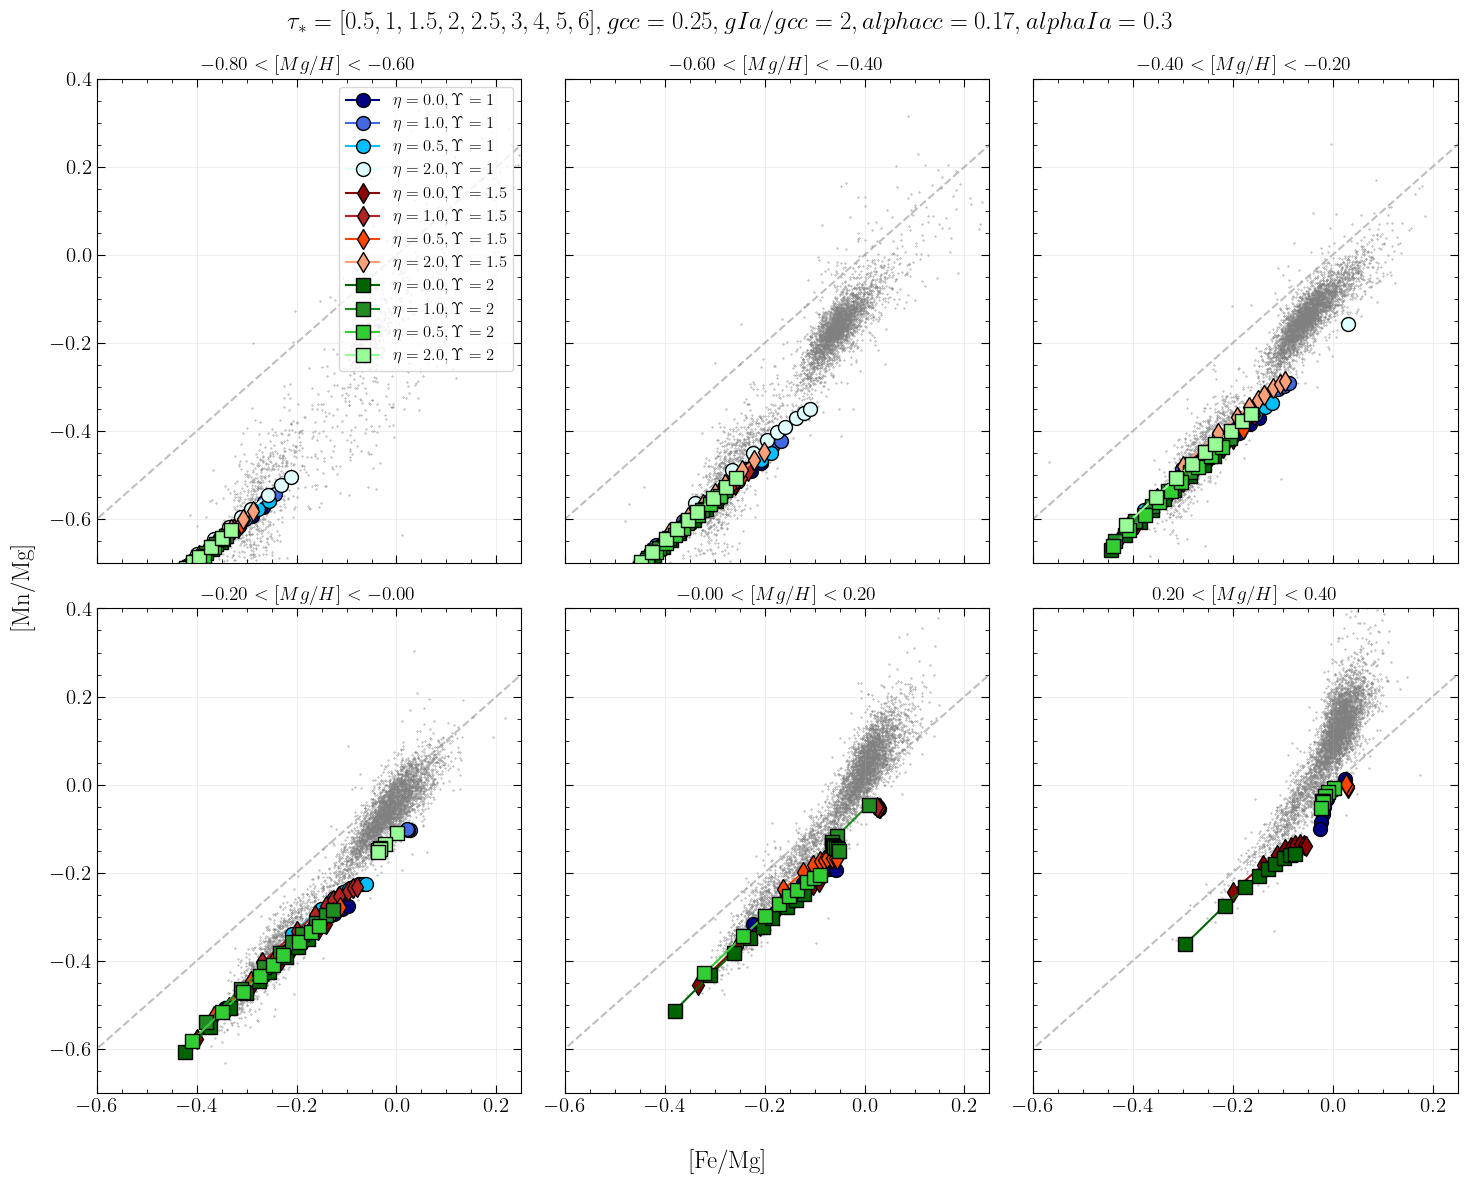

In [29]:
#gals = [gals_A, gals_B, gals_C,
# gals_D, gals_E, gals_F,
# gals_G, gals_H, gals_I,
# gals_J, gals_K, gals_L]
#gals = [gals_A, gals_D, gals_G, gals_J] #ups = 1
#gals = [gals_B, gals_E, gals_H, gals_K] #ups = 1.5
#gals = [gals_C, gals_F, gals_I, gals_L] #ups = 2
gals = [gals_A, gals_D, gals_G, gals_J, gals_B, gals_E, gals_H, gals_K, gals_C, gals_F, gals_I, gals_L]

gals_endpoints = {
    j: find_endpoints(gals[j], mg_h_big_bin_centers)
    for j in range(len(gals))
}

colors = ['navy', 'royalblue', 'deepskyblue', 'lightcyan', 'darkred', 'firebrick','orangered', 'lightsalmon', 'darkgreen', 'forestgreen', 'limegreen','palegreen', 'indigo', 'purple', 'mediumorchid', 'plum']
#colors = ['navy', 'royalblue', 'deepskyblue', 'lightcyan'] #ups = 1
#colors = ['darkred', 'firebrick','orangered', 'lightsalmon'] #ups = 1.5
#colors = ['indigo', 'purple', 'mediumorchid', 'plum']
#colors = ['darkgreen', 'forestgreen', 'limegreen','palegreen']


shapes = ['o', 'o', 'o', 'o', 'd', 'd', 'd', 'd', 's', 's', 's', 's']

fig, axes = plt.subplots(2, 3, figsize=(fig_x, fig_y), sharex=True, sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes):

    # Background data
    downsampled_data = downsample(data[data['MG_H_big_bin'] == i], 5000)
    ax.scatter(downsampled_data['FE_MG'], downsampled_data['MN_MG'], s=0.1, color='gray')

    # 1:1 line
    xs = np.linspace(-1, 1, 100)
    ax.plot(xs, xs, '--', alpha=0.5, color='gray')

    # τ_* sequences for all gcc values
    for j, (gals_j, endpoints_j, color, shape) in enumerate(
        zip(gals, gals_endpoints.values(), colors, shapes)
    ):
        idxs = endpoints_j[i]

        fe_mg = [gal.Fe_Mg[idx] for gal, idx in zip(gals_j, idxs)]
        mn_mg = [gal.Mn_Mg[idx] for gal, idx in zip(gals_j, idxs)]
        example_gal = gals_j[0]
        ax.plot(fe_mg, mn_mg, marker=shape, color=color, linewidth=1.5,
                label = rf"$\eta = {example_gal.eta_arr[0]}, \Upsilon = {example_gal.Upsilon}$",
                markeredgecolor='black', markersize=10)
        
    if i == 0:
        ax.legend(loc = 'upper right', fontsize=12)

    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.70, 0.40)

fig.supxlabel('[Fe/Mg]')
fig.supylabel('[Mn/Mg]')
fig.suptitle(rf"$\tau_* = {tau_stars}, gcc = {gals_A[0].g_cc_Mn}, gIa/gcc = {gals_A[0].g_ratio_Mn}, alphacc = {gals_A[0].alpha_cc_Mn}, alphaIa = {gals_A[0].alpha_Ia_Mn}$")
plt.tight_layout()
plt.show()


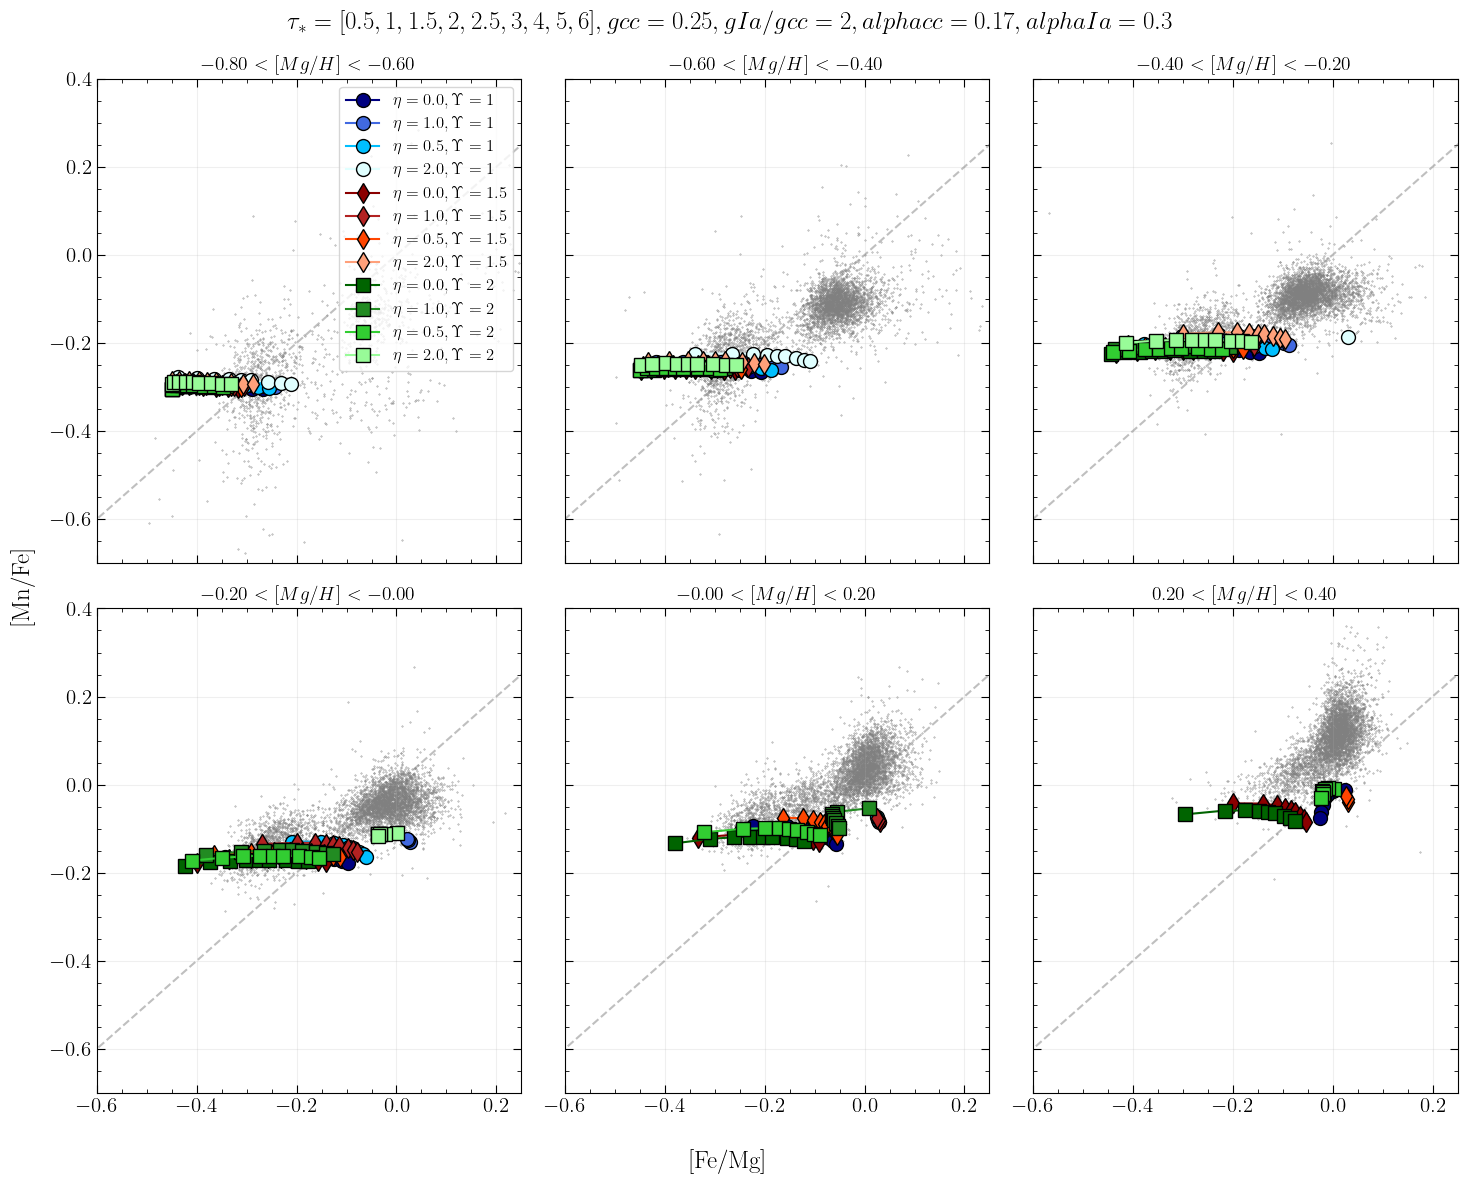

In [30]:
#gals = [gals_A, gals_B, gals_C,
# gals_D, gals_E, gals_F,
# gals_G, gals_H, gals_I,
# gals_J, gals_K, gals_L]
#gals = [gals_A, gals_D, gals_G, gals_J] #ups = 1
#gals = [gals_B, gals_E, gals_H, gals_K] #ups = 1.5
#gals = [gals_C, gals_F, gals_I, gals_L] #ups = 2
gals = [gals_A, gals_D, gals_G, gals_J, gals_B, gals_E, gals_H, gals_K, gals_C, gals_F, gals_I, gals_L]

gals_endpoints = {
    j: find_endpoints(gals[j], mg_h_big_bin_centers)
    for j in range(len(gals))
}

colors = ['navy', 'royalblue', 'deepskyblue', 'lightcyan', 'darkred', 'firebrick','orangered', 'lightsalmon', 'darkgreen', 'forestgreen', 'limegreen','palegreen', 'indigo', 'purple', 'mediumorchid', 'plum']
#colors = ['navy', 'royalblue', 'deepskyblue', 'lightcyan'] #ups = 1
#colors = ['darkred', 'firebrick','orangered', 'lightsalmon'] #ups = 1.5
#colors = ['indigo', 'purple', 'mediumorchid', 'plum']
#colors = ['darkgreen', 'forestgreen', 'limegreen','palegreen']


shapes = ['o', 'o', 'o', 'o', 'd', 'd', 'd', 'd', 's', 's', 's', 's']

fig, axes = plt.subplots(2, 3, figsize=(fig_x, fig_y), sharex=True, sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes):

    # Background data
    downsampled_data = downsample(data[data['MG_H_big_bin'] == i], 5000)
    ax.scatter(downsampled_data['FE_MG'], downsampled_data['MN_FE'], s=0.1, color='gray')

    # 1:1 line
    xs = np.linspace(-1, 1, 100)
    ax.plot(xs, xs, '--', alpha=0.5, color='gray')

    # τ_* sequences for all gcc values
    for j, (gals_j, endpoints_j, color, shape) in enumerate(
        zip(gals, gals_endpoints.values(), colors, shapes)
    ):
        idxs = endpoints_j[i]

        fe_mg = [gal.Fe_Mg[idx] for gal, idx in zip(gals_j, idxs)]
        mn_fe = [gal.Mn_Fe[idx] for gal, idx in zip(gals_j, idxs)]
        example_gal = gals_j[0]
        ax.plot(fe_mg, mn_fe, marker=shape, color=color, linewidth=1.5,
                label = rf"$\eta = {example_gal.eta_arr[0]}, \Upsilon = {example_gal.Upsilon}$",
                markeredgecolor='black', markersize=10)
        
    if i == 0:
        ax.legend(loc = 'upper right', fontsize=12)

    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.70, 0.40)

fig.supxlabel('[Fe/Mg]')
fig.supylabel('[Mn/Fe]')
fig.suptitle(rf"$\tau_* = {tau_stars}, gcc = {gals_A[0].g_cc_Mn}, gIa/gcc = {gals_A[0].g_ratio_Mn}, alphacc = {gals_A[0].alpha_cc_Mn}, alphaIa = {gals_A[0].alpha_Ia_Mn}$")
plt.tight_layout()
plt.show()
